*Sumário:*

1 - Bibliotecas

2 - Importação dos dados

3 - Tratamento dos dados

4 - Análise exploratória

5 - Modelo logit

### Bibliotecas

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Statsmodels:", sm.__version__)
print("Matplotlib:", matplotlib.__version__)

Pandas: 2.3.3
NumPy: 2.4.0
Statsmodels: 0.14.6
Matplotlib: 3.10.8


### Importação da base de dados

In [27]:
df = pd.read_csv(r"C:\Users\lucas\Desktop\3-data-science\1-projetos\olist\avaliacoes\txt\db_logit.txt")
df.head()

,order_id,review_id,review_score,data_entrega,data_estimada,saldo_entrega,status_nps,status_entrega
0,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-10,2017-10-18,-8.0,0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,8d5266042046a06655c8db133d120ba5,4,2018-08-07,2018-08-13,-6.0,0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,e73b67b67587f7644d5bd1a52deb1b01,5,2018-08-17,2018-09-04,-18.0,0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,359d03e676b3c069f62cadba8dd3f6e8,5,2017-12-02,2017-12-15,-13.0,0,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,e50934924e227544ba8246aeb3770dd4,5,2018-02-16,2018-02-26,-10.0,0,0.0


In [28]:
df.shape

(97015, 8)

### Tratamento dos dados

In [29]:
df.isna().sum()

order_id          0
review_id         0
review_score      0
data_entrega      8
data_estimada     0
saldo_entrega     8
status_nps        0
status_entrega    8
dtype: int64

In [30]:
df = df.dropna()
df.shape

(97007, 8)

In [31]:
df.drop(df.columns[:6], axis=1, inplace=True)
df.head()

,status_nps,status_entrega
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0


In [60]:
df['x'] = df['x'].astype(int)
df.head()

,y,x
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


### Análise exploratória

In [51]:
df['y'].value_counts()

y
0    76183
1    20824
Name: count, dtype: int64

In [52]:
df['x'].value_counts()

x
0    89142
1     7865
Name: count, dtype: int64

In [44]:
df.rename(columns={'status_nps':'y', 'status_entrega':'x'}, inplace=True)

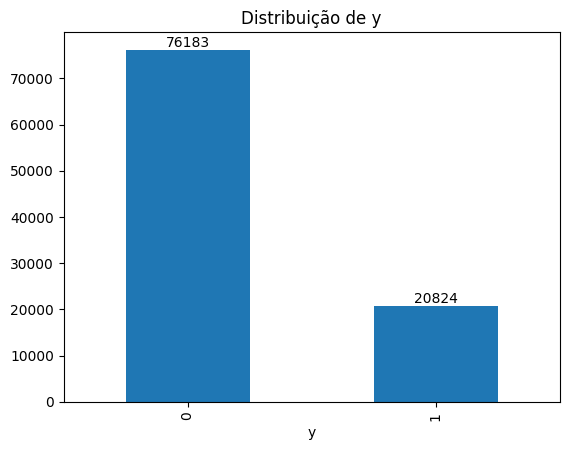

In [68]:
ax = df['y'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Distribuição de y')
plt.show()

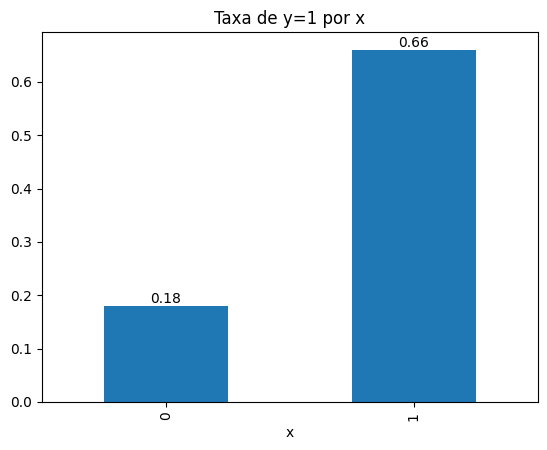

In [70]:
ax = round(df.groupby('x')['y'].mean(), 2).plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Taxa de y=1 por x')
plt.show()

In [ ]:
df['y'] = df['y'].astype('category')
df['x'] = df['x'].astype('category')
df.dtypes

### Modelo logit

In [71]:
df1 = df.copy()

In [ ]:
X = sm.add_constant(df1['x'])
y = df1['y']

modelo = sm.Logit(y, X)
resultado = modelo.fit(cov_type='HC3')

resultado.summary()

Optimization terminated successfully.
         Current function value: 0.478745
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                97007
Model:                          Logit   Df Residuals:                    97005
Method:                           MLE   Df Model:                            1
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                 0.07946
Time:                        20:33:14   Log-Likelihood:                -46442.
converged:                       True   LL-Null:                       -50451.
Covariance Type:                  HC3   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5476      0.009   -175.741      0.000      -1.565      -1.530
x              2.2082      0.025     87.037      0.000       2.158       2.258
==============================================================================
"""

In [74]:
odds_ratio = np.exp(resultado.params)
odds_ratio

const    0.212750
x        9.098914
dtype: float64